# Support Vector Machine (SVM) From Scratch — Heart Disease Dataset

## Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score

sns.set_theme(style="whitegrid")

## Loading the Dataset

In [2]:
df = pd.read_csv("heart.csv")
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


## Data Exploration

In [3]:
df.shape

(1025, 14)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [5]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


## Data Preprocessing

**Checking column data types**

In [6]:
df.select_dtypes(include='number').columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [7]:
df.select_dtypes(include='object').columns

Index([], dtype='object')

**Checking for missing values**

In [8]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


**Handling missing values (if any were found above)**

In [9]:
if df.isnull().sum().sum() > 0:
    before = df.shape[0]
    df = df.dropna()
    print(f"Removed {before - df.shape[0]} rows containing missing values.")
    print(f"New shape: {df.shape}")
else:
    print("No missing values found. No action needed.")

No missing values found. No action needed.


**Encoding categorical features**

`cp`, `slope`, and `thal` are categorical (multi-class) columns, so we one-hot encode them.

In [10]:
df = pd.get_dummies(df, columns=['cp', 'slope', 'thal'], drop_first=True, dtype=float)
df.head()

,age,sex,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,ca,target,cp_1,cp_2,cp_3,slope_1,slope_2,thal_1,thal_2,thal_3
0,52,1,125,212,0,1,168,0,1.0,2,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1,53,1,140,203,1,0,155,1,3.1,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,70,1,145,174,0,1,125,1,2.6,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,61,1,148,203,0,1,161,0,0.0,1,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
4,62,0,138,294,1,1,106,0,1.9,3,0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


**Separating features and target**

In [11]:
x = df.drop(columns=['target'])
y = df['target']

In [12]:
x.head()

,age,sex,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,ca,cp_1,cp_2,cp_3,slope_1,slope_2,thal_1,thal_2,thal_3
0,52,1,125,212,0,1,168,0,1.0,2,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1,53,1,140,203,1,0,155,1,3.1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,70,1,145,174,0,1,125,1,2.6,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,61,1,148,203,0,1,161,0,0.0,1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
4,62,0,138,294,1,1,106,0,1.9,3,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [13]:
y.head()

,target
0,0
1,0
2,0
3,0
4,0


**Train / Test Split**

In [14]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

## Data Analysis

**Target class distribution**

target
1    526
0    499
Name: count, dtype: int64


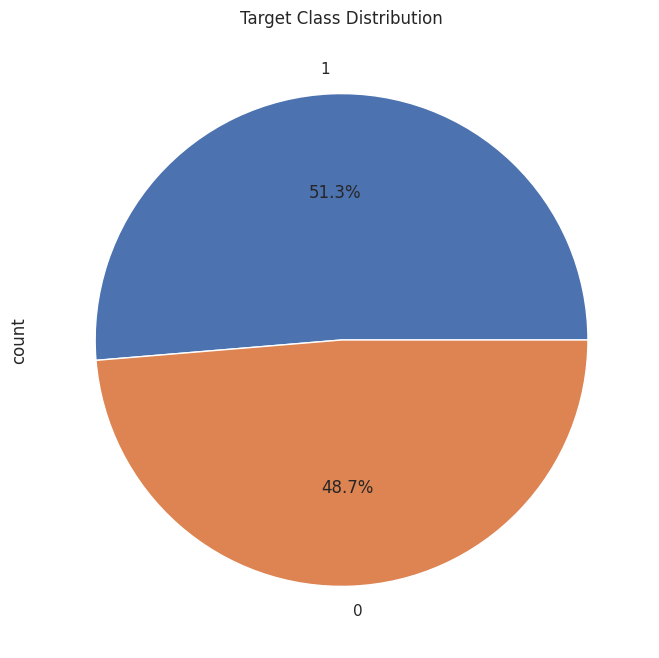

In [15]:
value_counts = df['target'].value_counts()
print(value_counts)
plt.figure(figsize=(8, 8))
value_counts.plot.pie(autopct='%1.1f%%')
plt.title('Target Class Distribution')
plt.show()

**Correlation heatmap**

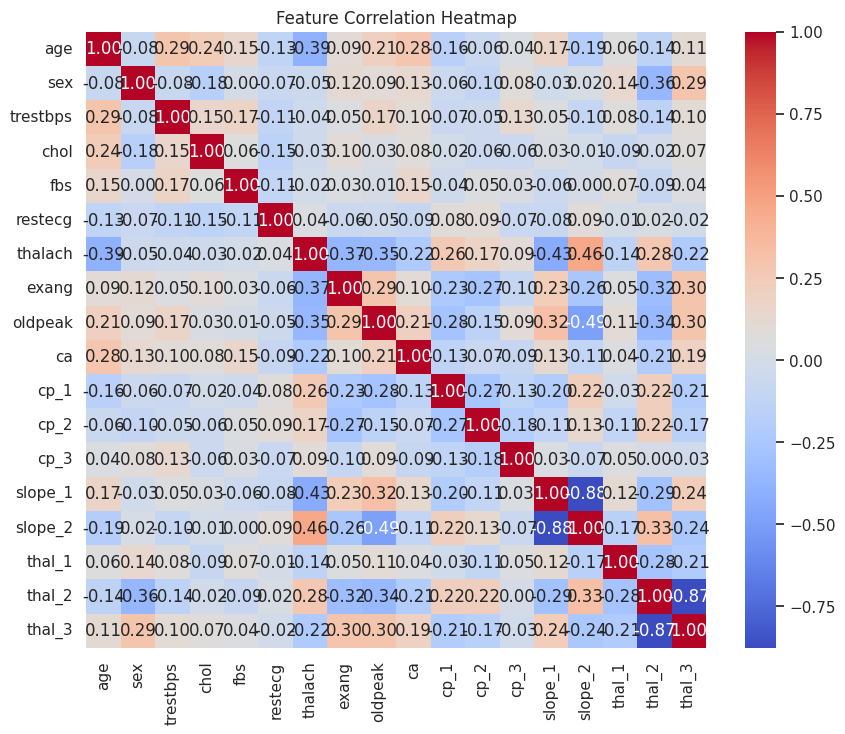

In [16]:
corr = x_train.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

**Function to detect highly correlated features**

Removes the first feature of any pair whose correlation exceeds the given threshold.

In [17]:
def correlation(dataframe, threshold):
    col_corr = set()  # names of correlated columns
    corr_matrix = dataframe.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold:
                colname = corr_matrix.columns[i]
                col_corr.add(colname)
    return col_corr

**Applying the function and dropping the flagged features (if any)**

In [18]:
corr_features = correlation(x_train, 0.8)
print(f"Highly correlated features to drop: {corr_features}")

if corr_features:
    x_train = x_train.drop(columns=corr_features)
    x_test = x_test.drop(columns=corr_features)
    print(f"Dropped {len(corr_features)} feature(s). New shape: {x_train.shape}")
else:
    print("No highly correlated features found. No action needed.")

x_train.head()

Highly correlated features to drop: {'slope_2', 'thal_3'}
Dropped 2 feature(s). New shape: (820, 16)


,age,sex,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,ca,cp_1,cp_2,cp_3,slope_1,thal_1,thal_2
835,49,1,118,149,0,0,126,0,0.8,3,0.0,1.0,0.0,0.0,0.0,1.0
137,64,0,180,325,0,1,154,1,0.0,0,0.0,0.0,0.0,0.0,0.0,1.0
534,54,0,108,267,0,0,167,0,0.0,0,0.0,1.0,0.0,0.0,0.0,1.0
495,59,1,135,234,0,1,161,0,0.5,0,0.0,0.0,0.0,1.0,0.0,0.0
244,51,1,125,245,1,0,166,0,2.4,0,0.0,1.0,0.0,1.0,0.0,1.0


## Outlier Detection & Handling

**Visualizing outliers with boxplots**

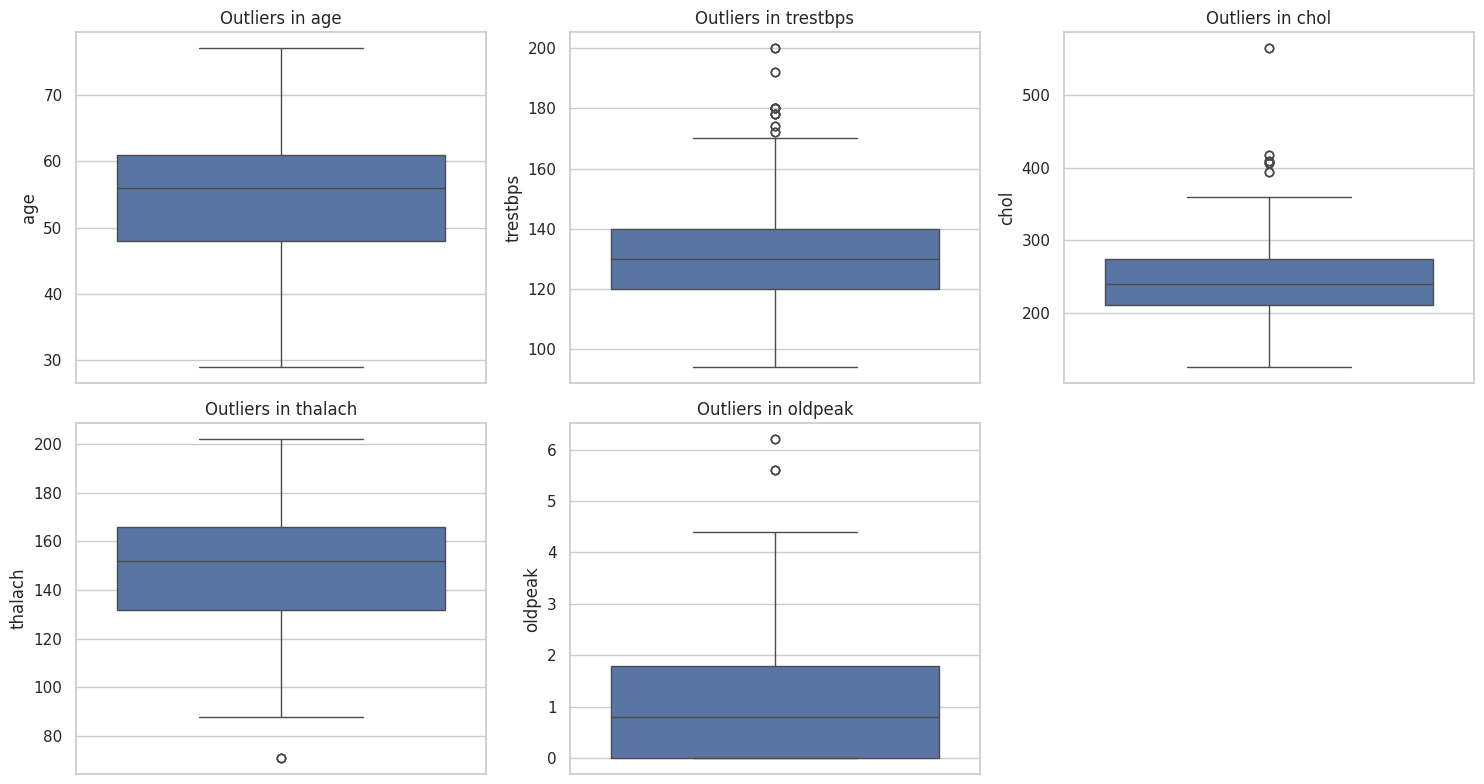

In [19]:
numeric_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

plt.figure(figsize=(15, 8))
for i, col in enumerate(numeric_cols):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Outliers in {col}')
plt.tight_layout()
plt.show()

**Trimming extreme values in `chol` and `trestbps`**

The boxplots above show clear high-end outliers in these two columns, so we cap them at the 99th percentile.

In [20]:
chol_cap = x_train['chol'].quantile(0.99)
trestbps_cap = x_train['trestbps'].quantile(0.99)

train_mask = (x_train['chol'] < chol_cap) & (x_train['trestbps'] < trestbps_cap)
x_train = x_train[train_mask]
y_train = y_train[train_mask]

print(f"Training samples after trimming: {x_train.shape[0]}")

Training samples after trimming: 796


## Standardization

In [21]:
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [22]:
x_train[:5]

array([[-0.56377585,  0.63356803, -0.78064748, -2.05743221, -0.40465132,
        -1.00439364, -1.01215942, -0.71444834, -0.19721826,  2.16560518,
        -0.43161223,  1.60797562, -0.29819337, -0.95575182, -0.26708133,
         0.9296067 ],
       [-0.01981758, -1.57836246, -1.39449257,  0.55766553, -0.40465132,
        -1.00439364,  0.77253099, -0.71444834, -0.90635767, -0.72186839,
        -0.43161223,  1.60797562, -0.29819337, -0.95575182, -0.26708133,
         0.9296067 ],
       [ 0.5241407 ,  0.63356803,  0.26288919, -0.17367537, -0.40465132,
         0.91286616,  0.51135678, -0.71444834, -0.46314554, -0.72186839,
        -0.43161223, -0.62189998, -0.29819337,  1.04629673, -0.26708133,
        -1.07572374],
       [-0.34619254,  0.63356803, -0.35095591,  0.07010493,  2.47126341,
        -1.00439364,  0.72900196, -0.71444834,  1.22106056, -0.72186839,
        -0.43161223,  1.60797562, -0.29819337,  1.04629673, -0.26708133,
         0.9296067 ],
       [-1.43410908,  0.63356803,  0

## Converting to Arrays

In [23]:
x_train = np.array(x_train)
x_test = np.array(x_test)

# SVM expects labels in {-1, 1}, not {0, 1}
y_train = np.where(np.array(y_train) <= 0, -1, 1)
y_test = np.where(np.array(y_test) <= 0, -1, 1)

## Baseline: SVM with scikit-learn

Before implementing SVM from scratch, we train scikit-learn's `SVC` as a reference point.

In [24]:
from sklearn.svm import SVC

baseline_model = SVC()
baseline_model.fit(x_train, y_train)

SVC()

In [25]:
baseline_preds = baseline_model.predict(x_test)

baseline_acc = accuracy_score(y_test, baseline_preds)
baseline_f1 = f1_score(y_test, baseline_preds, average='weighted')

print(f"Baseline Accuracy: {baseline_acc:.4f}")
print(f"Baseline F1 Score: {baseline_f1:.4f}")

Baseline Accuracy: 0.9024
Baseline F1 Score: 0.9021


## Support Vector Machine — Implemented From Scratch

A linear SVM trained with gradient descent on the hinge loss, using a regularization parameter `C`.

In [26]:
class SVM:
    def __init__(self, learning_rate=1e-3, C=1.0, n_iters=1000):
        self.lr = learning_rate
        self.C = C
        self.n_iters = n_iters
        self.w = None
        self.b = None
        self.loss_history = []

    def _init_weights_bias(self, X):
        n_features = X.shape[1]
        self.w = np.zeros(n_features)
        self.b = 0.0

    def _satisfies_margin(self, x_i, y_i):
        return y_i * (np.dot(x_i, self.w) + self.b) >= 1

    def _get_gradients(self, satisfied, x_i, y_i):
        if satisfied:
            dw = self.w
            db = 0
            return dw, db

        dw = self.w - self.C * y_i * x_i
        db = -self.C * y_i
        return dw, db

    def _update_weights_bias(self, dw, db):
        self.w -= self.lr * dw
        self.b -= self.lr * db

    def _compute_loss(self, X, y):
        margins = 1 - y * (np.dot(X, self.w) + self.b)
        hinge_loss = np.sum(np.maximum(0, margins))
        return 0.5 * np.dot(self.w, self.w) + (self.C / len(y)) * hinge_loss

    def fit(self, X, y):
        self._init_weights_bias(X)

        for epoch in range(self.n_iters):
            for idx, x_i in enumerate(X):
                satisfied = self._satisfies_margin(x_i, y[idx])
                dw, db = self._get_gradients(satisfied, x_i, y[idx])
                self._update_weights_bias(dw, db)

            epoch_loss = self._compute_loss(X, y)
            self.loss_history.append(epoch_loss)

            if (epoch + 1) % 200 == 0 or epoch == 0:
                print(f"Epoch {epoch + 1}/{self.n_iters} | Loss: {epoch_loss:.4f}")

    def predict(self, X):
        estimate = np.dot(X, self.w) + self.b
        return np.sign(estimate)

## Training the Model

In [27]:
svm = SVM(learning_rate=0.001, C=1.0, n_iters=1000)
svm.fit(x_train, y_train)

Epoch 1/1000 | Loss: 0.5762
Epoch 200/1000 | Loss: 0.5732
Epoch 400/1000 | Loss: 0.5734
Epoch 600/1000 | Loss: 0.5734
Epoch 800/1000 | Loss: 0.5732
Epoch 1000/1000 | Loss: 0.5733


## Model Evaluation

In [28]:
predictions = svm.predict(x_test)

acc = accuracy_score(y_test, predictions)
f1 = f1_score(y_test, predictions, average='weighted')

print(f"Test Accuracy: {acc:.4f}")
print(f"Test F1 Score: {f1:.4f}")

Test Accuracy: 0.8098
Test F1 Score: 0.8084


## Visualization

**Loss curve over training epochs**

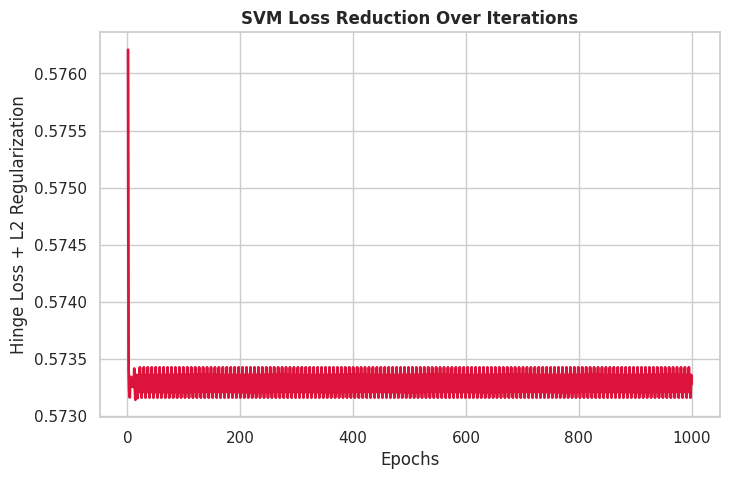

In [29]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, svm.n_iters + 1), svm.loss_history, color='crimson', linewidth=2)
plt.title('SVM Loss Reduction Over Iterations', fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Hinge Loss + L2 Regularization')
plt.show()

**Confusion matrix**

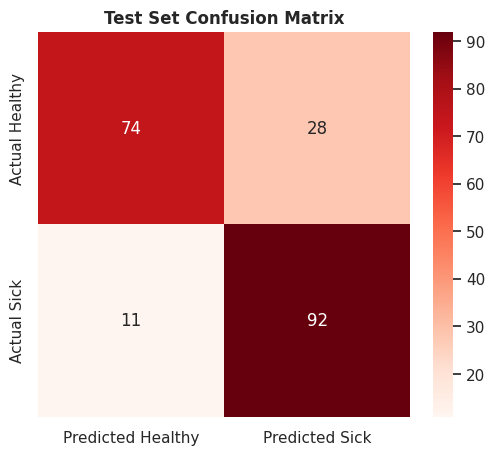

In [30]:
tp = np.sum((predictions == 1) & (y_test == 1))
tn = np.sum((predictions == -1) & (y_test == -1))
fp = np.sum((predictions == 1) & (y_test == -1))
fn = np.sum((predictions == -1) & (y_test == 1))

conf_matrix = np.array([[tn, fp], [fn, tp]])

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Predicted Healthy', 'Predicted Sick'],
            yticklabels=['Actual Healthy', 'Actual Sick'])
plt.title('Test Set Confusion Matrix', fontweight='bold')
plt.show()